# Fuzzy Cognitive Map: Tool to figure out what happens when you quit your job during studying

This notebook uses a simulation to see what happens when a student quits their part-time job to study full time.

6 concepts:
- Financial Stress: without job, financial stress is high
- Study Focus: without job, more concentration on studying
- Mental Energy: without job and no context switching, mental energy is high
- Academic Performance: academic performance increases
- Social Life: more time for meeting friends, less money though
- Sleep Quality

The intervention is quitting the job. The simulation then shows where the system settles.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fcmpy import FcmSimulator, FcmIntervention


## Concepts ##
- 0.0 = completely absent
- 1.0 = maximum
- 0.5 = moderate

In [2]:
concepts = [
    'Financial_Stress',
    'Study_Focus',
    'Mental_Energy',
    'Academic_Performance',
    'Social_Life',
    'Sleep_Quality'
]


## Weight Matrix


In [9]:

weights = np.array([
    [ 0,   -0.6,  -0.7,   0,    -0.4,  -0.5],  # Financial_Stress
    [ 0,    0,     0.4,   0.8,   0,     0  ],   # Study_Focus
    [-0.4,  0.7,   0,     0,     0.4,   0.5],   # Mental_Energy
    [-0.3,  0,     0.5,   0,     0,     0  ],   # Academic_Performance
    [ 0,    0,     0.5,   0,     0,     0.3],   # Social_Life
    [ 0,    0.5,   0.6,   0,     0,     0  ]    # Sleep_Quality
])

In [10]:
weight_matrix = pd.DataFrame(weights, columns=concepts)

weight_matrix.index = concepts
print(weight_matrix)

                      Financial_Stress  Study_Focus  Mental_Energy  \
Financial_Stress                   0.0         -0.6           -0.7   
Study_Focus                        0.0          0.0            0.4   
Mental_Energy                     -0.4          0.7            0.0   
Academic_Performance              -0.3          0.0            0.5   
Social_Life                        0.0          0.0            0.5   
Sleep_Quality                      0.0          0.5            0.6   

                      Academic_Performance  Social_Life  Sleep_Quality  
Financial_Stress                       0.0         -0.4           -0.5  
Study_Focus                            0.8          0.0            0.0  
Mental_Energy                          0.0          0.4            0.5  
Academic_Performance                   0.0          0.0            0.0  
Social_Life                            0.0          0.0            0.3  
Sleep_Quality                          0.0          0.0            0.0 


## Initial State


In [11]:
init_state = {
    'Financial_Stress':      0.2,   # money is fine, has job income
    'Study_Focus':           0.3,   # hard to focus, always splitting attention
    'Mental_Energy':         0.3,   # drained from doing two things at once
    'Academic_Performance':  0.4,   # getting by but not thriving
    'Social_Life':           0.5,   # still has some time for people
    'Sleep_Quality':         0.5    # moderate, tired but okay
}


## Baseline Simulation

This shows what happens to the system if the student keeps working


In [25]:
sim = FcmSimulator()

result_baseline = sim.simulate(initial_state=init_state, weight_matrix=weight_matrix, transfer='sigmoid', inference='mKosko',thresh=0.001,iterations=50, l=1
)

print(result_baseline)

The values converged in the 8 state (e <= 0.001)
   Financial_Stress  Study_Focus  Mental_Energy  Academic_Performance  \
0          0.200000     0.300000       0.300000              0.400000   
1          0.490001     0.654753       0.736916              0.654753   
2          0.499702     0.770421       0.845536              0.764688   
3          0.483027     0.806300       0.876547              0.799156   
4          0.473191     0.818386       0.886692              0.809104   
5          0.468986     0.822795       0.890315              0.812115   
6          0.467353     0.824461       0.891664              0.813111   
7          0.466738     0.825095       0.892173              0.813464   

   Social_Life  Sleep_Quality  
0     0.500000       0.500000  
1     0.631812       0.668188  
2     0.674932       0.727344  
3     0.692805       0.750773  
4     0.700612       0.760491  
5     0.703915       0.764485  
6     0.705255       0.766083  
7     0.705781       0.766708  


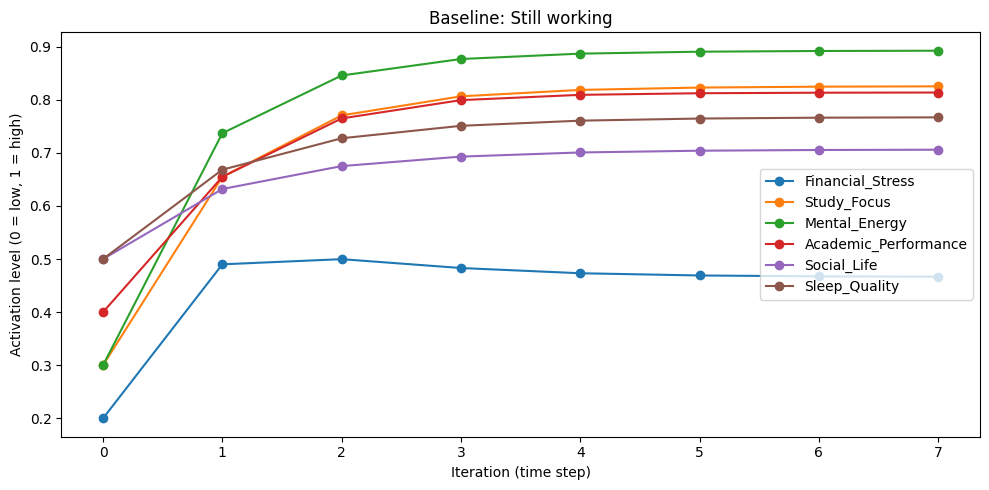

In [14]:
# Plot baseline
result_baseline.plot(marker='o', figsize=(10, 5))
plt.title("Baseline: Still working")
plt.xlabel("Iteration (time step)")
plt.ylabel("Activation level (0 = low, 1 = high)")
plt.legend(loc='center right')
plt.tight_layout()
plt.show()


## Intervention: Quit the Job

Now we model what quitting does **immediately** to the system.

Quitting the job has three direct effects:
1. Financial stress goes up
2. Study focus jumps up
3. Mental energy gets a boost

Everything else (performance, social life, sleep) is not directly changed by quitting.



In [18]:
inter = FcmIntervention(FcmSimulator)

inter.initialize(initial_state=init_state,weight_matrix=weight_matrix,transfer='sigmoid',inference='mKosko',thresh=0.001,iterations=50,l=1
)

The values converged in the 8 state (e <= 0.001)


In [19]:
inter.add_intervention(
    'Quit_Job',
    type='continuous',
    impact={
        'Financial_Stress': +0.6,   # big immediate jump in money anxiety
        'Study_Focus':      +0.5,   # freed up to actually concentrate
        'Mental_Energy':    +0.3    # less context switching = more headspace
    },
    effectiveness=1
)

/Users/isabellebustamante/miniconda3/envs/ai_env/lib/python3.10/site-packages/fcmpy/intervention/interventionConstructor.py:109: FutureWarning: The series.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  temp_vector = temp_vector.append(pd.Series({'intervention': effectiveness})).to_dict()


In [20]:
inter.test_intervention('Quit_Job', iterations=50)

The values converged in the 6 state (e <= 0.001)



##  Compare Results


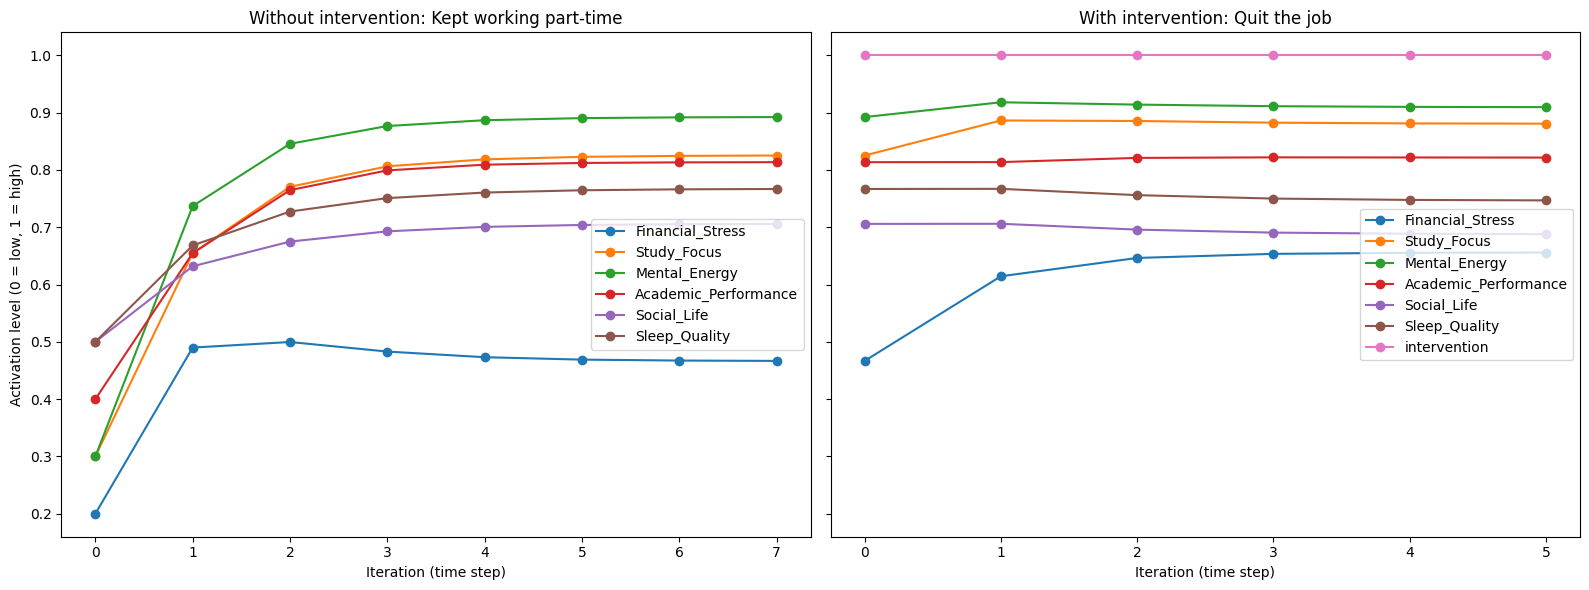

In [26]:
baseline   = inter.test_results['baseline']
quit_job   = inter.test_results['Quit_Job']


fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

baseline.plot(ax=axes[0], marker='o')
axes[0].set_title("Without intervention: Kept working part-time")
axes[0].set_xlabel("Iteration (time step)")
axes[0].set_ylabel("Activation level (0 = low, 1 = high)")
axes[0].legend(loc='center right')

quit_job.plot(ax=axes[1], marker='o')
axes[1].set_title("With intervention: Quit the job")
axes[1].set_xlabel("Iteration (time step)")
axes[1].legend(loc='center right')

plt.tight_layout()
plt.show()

In [24]:
print("Where the system settles without quitting")
print(baseline.iloc[-1].round(3))

print()

print("Where the system settles after quitting")
print(quit_job.iloc[-1].round(3))

Where the system settles without quitting
Financial_Stress        0.467
Study_Focus             0.825
Mental_Energy           0.892
Academic_Performance    0.813
Social_Life             0.706
Sleep_Quality           0.767
Name: 7, dtype: float64

Where the system settles after quitting
Financial_Stress        0.656
Study_Focus             0.881
Mental_Energy           0.909
Academic_Performance    0.822
Social_Life             0.688
Sleep_Quality           0.747
intervention            1.000
Name: 5, dtype: float64
